In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tangram as tg
import torch
from sklearn.neighbors import NearestNeighbors

sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, facecolor='white')


In [3]:
# Load the three distinct files
adata_v1 = sc.read_h5ad("v1genes_filtered.h5ad")
adata_prime = sc.read_h5ad("primegenes_filtered.h5ad")
adata_dual = sc.read_h5ad("allgenes_filtered.h5ad")

print(f"V1 shape: {adata_v1.shape}")
print(f"Prime shape: {adata_prime.shape}")
print(f"Dual shape: {adata_dual.shape}")

V1 shape: (644069, 480)
Prime shape: (510205, 5001)
Dual shape: (815850, 5481)


In [4]:
adata_dual


AnnData object with n_obs × n_vars = 815850 × 5481
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample'
    var: 'name'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts'

In [5]:
adata = adata_dual

In [6]:
adata_v1

AnnData object with n_obs × n_vars = 644069 × 480
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample'
    var: 'name', 'is_v1_gene'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts'

In [7]:
adata_prime

AnnData object with n_obs × n_vars = 510205 × 5001
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample'
    var: 'name', 'is_v1_gene', 'is_prime_gene'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts'

In [8]:
sum(adata_prime.var["is_prime_gene"])


5001

In [9]:
adata_dual.obs["sample"].value_counts()

sample
PDL034D    140078
PDL095D     99992
PDL032D     75328
PDL072      69103
PDL018D     60113
PDL026A     54095
PDL031A     53161
PDL077      46331
PDL040A     43496
PDL061      38055
PDL029A     29232
PDL085A     28723
PDL055T     23157
PDL047T     20259
PDL042D     19098
PDL097       8645
PDL033T      6264
UNSURE        720
Name: count, dtype: int64

In [10]:
print(adata_dual.var["name"][523])


ACHE-prime-with-v1-seg


In [11]:
adata = adata[adata.obs['sample'] != 'UNSURE'].copy()

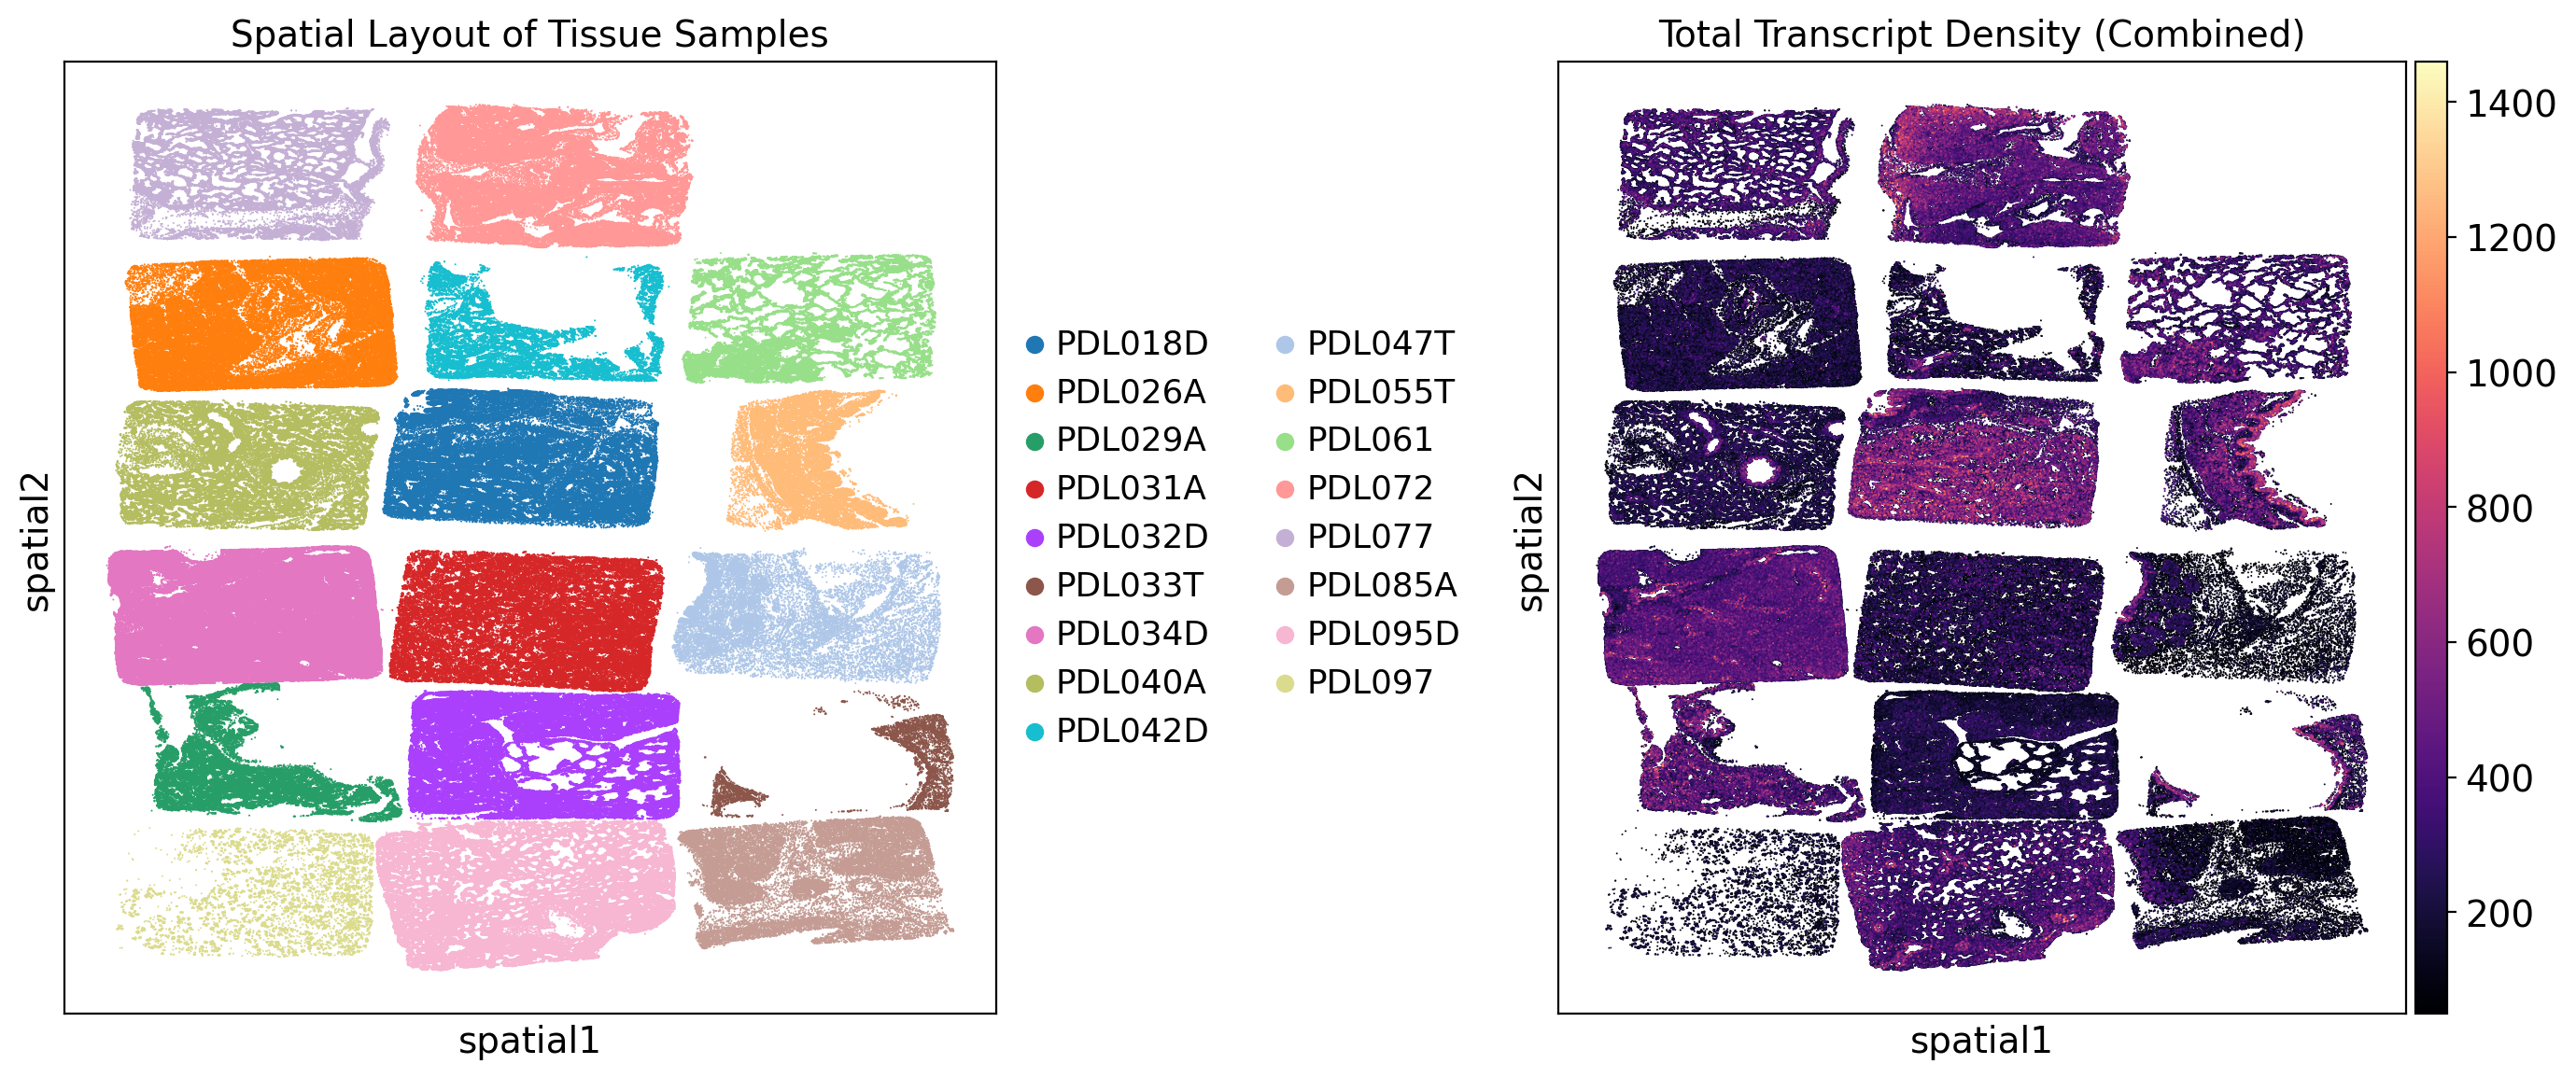

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the physical tissue layout colored by Sample ID
sc.pl.embedding(adata, basis='spatial', color='sample', ax=axes[0], show=False, s=2)
axes[0].set_title("Spatial Layout of Tissue Samples")

# Plot the total transcript density (Combined Prime + V1)
sc.pl.embedding(adata, basis='spatial', color='n_counts_combined', cmap='magma', ax=axes[1], show=False, s=2)
axes[1].set_title("Total Transcript Density (Combined)")

plt.tight_layout()
plt.show()


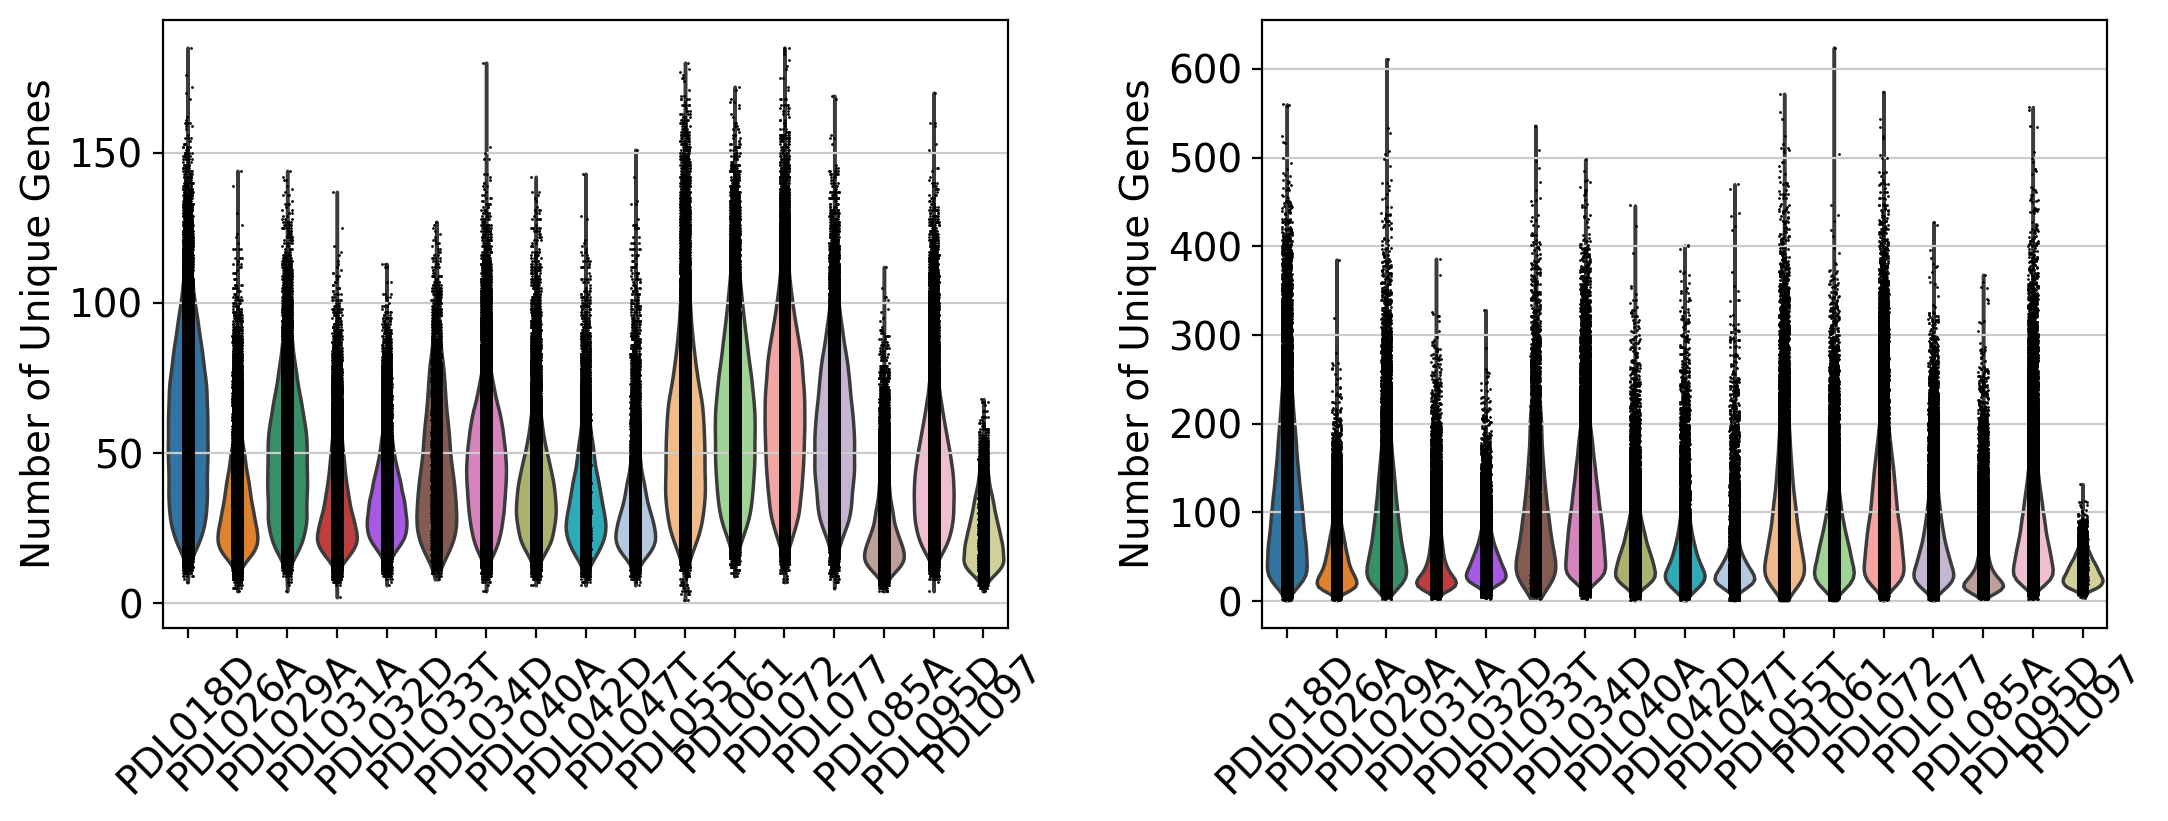

Mean Expression Statistics Across Entire Dataset:
Average V1 genes: 45.6
Average Prime genes: 77.8


In [26]:
# Create a clean violin plot comparing the number of detected genes
# sc.pl.violin(adata, 
#              keys=['n_genes_v1_prime', 'n_genes_prime_with_v1_seg'], 
#              groupby='sample', 
#              rotation=45,
#             #  title="Detected Genes per Cell (V1 vs. Prime Chemistry)",
#              ylabel="Number of Unique Genes")
sc.pl.violin(
    adata,
    keys=['n_genes_v1_prime', 'n_genes_prime_with_v1_seg'],
    groupby='sample',
    rotation=45,
    show=False,
    ylabel="Number of Unique Genes"
)
plt.gcf().set_size_inches(14, 4)
plt.tight_layout()
plt.show()
             

print("Mean Expression Statistics Across Entire Dataset:")
print(f"Average V1 genes: {adata.obs['n_genes_v1_prime'].mean():.1f}")
print(f"Average Prime genes: {adata.obs['n_genes_prime_with_v1_seg'].mean():.1f}")


In [12]:
adata_backup = adata.copy()

In [13]:
adata_backup

AnnData object with n_obs × n_vars = 815130 × 5481
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample'
    var: 'name'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts'

In [ ]:
# adata = adata_backup.copy

In [ ]:
# # 1. Subsample to 10,000 cells for rapid midterm benchmarking
# sc.pp.subsample(adata, n_obs=10000, random_state=42)
# print(f"Subsampled down to {adata.shape[0]} cells for rapid benchmarking.\n")


In [14]:
# 2. Extract the raw gene names using list comprehensions
v1_genes_raw = [g for g in adata.var_names if g.endswith('-v1-prime')]
prime_genes_raw = [g for g in adata.var_names if g.endswith('-prime-with-v1-seg')]
print(f"Detected {len(v1_genes_raw)} V1 genes and {len(prime_genes_raw)} Prime genes.")


Detected 480 V1 genes and 5001 Prime genes.


In [15]:
# 3. Create the "Spatial Target" (V1 Data)
ad_sp = adata[:, v1_genes_raw].copy()
ad_sp.X = ad_sp.layers['counts'].copy() # Tangram needs raw counts!

# Clean the V1 var_names by removing the suffix
ad_sp.var_names = [g.replace('-v1-prime', '') for g in ad_sp.var_names]


# 4. Create the "Reference" (Prime Data)
ad_sc = adata[:, prime_genes_raw].copy()
ad_sc.X = ad_sc.layers['counts'].copy() # Tangram needs raw counts!

# Clean the Prime var_names by removing the suffix
ad_sc.var_names = [g.replace('-prime-with-v1-seg', '') for g in ad_sc.var_names]


# 5. Find the exact biological overlap (The Anchor)
overlapping_genes = list(set(ad_sp.var_names) & set(ad_sc.var_names))
print(f"Number of anchoring genes for Tangram mapping: {len(overlapping_genes)}")

if len(overlapping_genes) < 50:
    print("WARNING: Very low overlap. Tangram may struggle to find accurate alignments.")


Number of anchoring genes for Tangram mapping: 239


In [17]:
overlapping_genes

['ICAM1',
 'HMGA1',
 'TBX4',
 'BANK1',
 'TREM2',
 'MLPH',
 'CD8B',
 'TNFRSF13C',
 'WNT2',
 'WNT5A',
 'PDGFRA',
 'HMOX1',
 'SEMA3A',
 'PECAM1',
 'FGFR4',
 'PROX1',
 'FASN',
 'SRSF1',
 'TCF21',
 'NOTCH3',
 'HOPX',
 'LTBP2',
 'HDAC9',
 'STAT6',
 'FKBP11',
 'CXCR4',
 'TSPAN8',
 'KDR',
 'SHH',
 'SLIT3',
 'CD4',
 'GJA5',
 'VEGFA',
 'RUNX1',
 'MFAP5',
 'TCL1A',
 'SHANK3',
 'EPAS1',
 'TMPRSS2',
 'EPCAM',
 'HSPG2',
 'CD151',
 'ITGA3',
 'WNT3A',
 'IRF1',
 'TGFB3',
 'EREG',
 'BCL2L1',
 'IFIT1',
 'CD28',
 'MRC1',
 'NFKB1',
 'HEY1',
 'ELN',
 'IDH1',
 'CCL22',
 'NUTF2',
 'SFRP4',
 'LCK',
 'CTHRC1',
 'INHBA',
 'INMT',
 'PDGFRB',
 'GCLM',
 'XBP1',
 'NUCB2',
 'PIM2',
 'ADAMTS1',
 'LTA4H',
 'MS4A1',
 'POSTN',
 'IFT57',
 'CD247',
 'FCER1A',
 'FGF10',
 'WT1',
 'SMPD3',
 'APLNR',
 'CXCL6',
 'SNAI2',
 'ELANE',
 'FILIP1L',
 'ID4',
 'CDH1',
 'MEG3',
 'BCL2L11',
 'FOXJ1',
 'IRF7',
 'COL2A1',
 'HIF1A',
 'PROM1',
 'PTGS1',
 'CD3E',
 'CD163',
 'CD19',
 'MUC5B',
 'SNAI1',
 'PTTG1',
 'TP73',
 'CD1E',
 'TRPC6',
 'ZE

In [18]:
import os

print("Saving master object to disk. This might take a minute...")

# Write the object to an h5ad file
ad_sp.write_h5ad("GSE315411_Midterm_Checkpoint.h5ad")

print(f"Checkpoint saved successfully! File size: {os.path.getsize('GSE315411_Midterm_Checkpoint.h5ad') / (1024**3):.2f} GB")
print("You can safely breathe now.")

Saving master object to disk. This might take a minute...
Checkpoint saved successfully! File size: 1.03 GB
You can safely breathe now.


In [20]:
import gc
import torch
import numpy as np
from sklearn.neighbors import NearestNeighbors

samples = ad_sp.obs['sample'].unique()
print(f"Starting cropped spatial loop across {len(samples)} samples...\n")

n_cells = ad_sp.shape[0]
n_prime_genes = ad_sc.shape[1]
crop_size = 10000

# 1. Pre-allocate arrays with NaNs (so we know which cells were skipped)
ad_sp.obsm['imputed_tangram_prime'] = np.full((n_cells, n_prime_genes), np.nan, dtype=np.float32)
ad_sp.obsm['imputed_knn_prime'] = np.full((n_cells, n_prime_genes), np.nan, dtype=np.float32)

# Array to track which cells across the whole dataset actually made it into a crop
master_crop_mask = np.zeros(n_cells, dtype=bool)

for idx, sample_id in enumerate(samples):
    print(f"--- Processing Sample {idx+1}/{len(samples)}: {sample_id} ---")
    
    # 2. Find the Absolute Indices for this specific sample
    sample_mask = (ad_sp.obs['sample'] == sample_id).values
    absolute_sample_indices = np.where(sample_mask)[0]
    
    ad_sp_sample = ad_sp[sample_mask].copy()
    ad_sc_sample = ad_sc[sample_mask].copy()
    
    n_sample_cells = ad_sp_sample.shape[0]
    if n_sample_cells < 15:
        print(f"Skipping - only {n_sample_cells} cells.")
        continue

    # 3. The Spatial Center Crop
    coords = ad_sp_sample.obsm['spatial']
    center_x, center_y = np.median(coords[:, 0]), np.median(coords[:, 1])
    distances = np.sqrt((coords[:, 0] - center_x)**2 + (coords[:, 1] - center_y)**2)
    
    # Find the indices of the closest 10k cells (relative to this sample)
    n_to_keep = min(crop_size, n_sample_cells)
    closest_rel_indices = np.argsort(distances)[:n_to_keep]
    
    # Map those relative indices BACK to the master 815k absolute indices
    closest_abs_indices = absolute_sample_indices[closest_rel_indices]
    
    # 4. Crop the objects for the models
    ad_sp_crop = ad_sp_sample[closest_rel_indices].copy()
    ad_sc_crop = ad_sc_sample[closest_rel_indices].copy()
    
    print(f"Cropped core down to {n_to_keep} central cells.")

    # ==========================================
    # A. TANGRAM IMPUTATION (GPU)
    # ==========================================
    tg.pp_adatas(ad_sc_crop, ad_sp_crop, genes=overlapping_genes)
    ad_map = tg.map_cells_to_space(
        ad_sc_crop, ad_sp_crop, mode="cells", density_prior='uniform', 
        num_epochs=300, device='cuda' 
    )
    ad_imputed = tg.project_genes(adata_map=ad_map, adata_sc=ad_sc_crop)
    tangram_res = ad_imputed.X.toarray() if hasattr(ad_imputed.X, 'toarray') else np.array(ad_imputed.X)

    # ==========================================
    # B. SPATIAL k-NN IMPUTATION (CPU)
    # ==========================================
    crop_coords = ad_sp_crop.obsm['spatial']
    k = min(10, n_to_keep - 1)
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='kd_tree').fit(crop_coords)
    _, indices = nbrs.kneighbors(crop_coords)

    prime_counts = ad_sc_crop.X.toarray() if hasattr(ad_sc_crop.X, 'toarray') else np.array(ad_sc_crop.X)
    knn_res = np.zeros_like(prime_counts, dtype=np.float32)

    for i in range(len(crop_coords)):
        neighbor_idx = indices[i, 1:] 
        knn_res[i] = np.mean(prime_counts[neighbor_idx], axis=0)

# ==========================================
    # C. SLOT ANSWERS AND CLEAN MEMORY
    # ==========================================
    # 1. Find exactly which genes survived Tangram's zero-variance filter
    surviving_genes = ad_sc_crop.var_names
    
    # 2. Get their absolute column indices in the global master array
    global_gene_indices = ad_sc.var_names.get_indexer(surviving_genes)
    
    # 3. Create a 2D mesh to insert the data into the exact Row/Col intersections
    insertion_mesh = np.ix_(closest_abs_indices, global_gene_indices)
    
    # 4. Slot the answers safely
    ad_sp.obsm['imputed_tangram_prime'][insertion_mesh] = tangram_res
    ad_sp.obsm['imputed_knn_prime'][insertion_mesh] = knn_res
    
    # Mark these cells as evaluated
    master_crop_mask[closest_abs_indices] = True

    del ad_sp_sample, ad_sc_sample, ad_sp_crop, ad_sc_crop, ad_map, ad_imputed
    del tangram_res, knn_res, distances, coords, crop_coords, insertion_mesh
    gc.collect()
    torch.cuda.empty_cache()

# Save the final tracking mask to the metadata
ad_sp.obs['in_10k_crop'] = master_crop_mask
print("\nAll cropped samples processed safely!")

Starting cropped spatial loop across 17 samples...

--- Processing Sample 1/17: PDL095D ---
Cropped core down to 10000 central cells.
filtered out 16 genes that are detected in less than 1 cells


INFO:root:239 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:239 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 239 genes and uniform density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.197, KL reg: 0.000
Score: 0.969, KL reg: 0.002
Score: 0.976, KL reg: 0.001


INFO:root:Saving results..


--- Processing Sample 2/17: PDL085A ---
Cropped core down to 10000 central cells.
filtered out 5 genes that are detected in less than 1 cells


...

--- Processing Sample 17/17: PDL072 ---
Cropped core down to 10000 central cells.
filtered out 18 genes that are detected in less than 1 cells


INFO:root:237 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:237 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
INFO:root:Allocate tensors for mapping.
INFO:root:Begin training with 237 genes and uniform density_prior in cells mode...
INFO:root:Printing scores every 100 epochs.


Score: 0.242, KL reg: 0.000
Score: 0.971, KL reg: 0.001
Score: 0.979, KL reg: 0.001


INFO:root:Saving results..



All cropped samples processed safely!


In [21]:
import os

print("Saving master object to disk. This might take a minute...")

# Write the object to an h5ad file
ad_sp.write_h5ad("GSE315411_Midterm_Checkpoint2.h5ad")

print(f"Checkpoint saved successfully! File size: {os.path.getsize('GSE315411_Midterm_Checkpoint2.h5ad') / (1024**3):.2f} GB")
print("You can safely breathe now.")

Saving master object to disk. This might take a minute...
Checkpoint saved successfully! File size: 31.40 GB
You can safely breathe now.


In [ ]:
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Starting low-memory evaluation...")

# 1. Get the boolean mask of cells we actually predicted
eval_mask = ad_sp.obs['in_10k_crop'].values
n_genes = ad_sc.shape[1]

tangram_corrs, knn_corrs = [], []

# 2. Loop through one gene at a time! (Saves massive amounts of RAM)
for i in range(n_genes):
    # Print progress every 500 genes so you know it hasn't frozen
    if i % 500 == 0:
        print(f"Processing gene {i}/{n_genes}...")
        
    # Extract True Counts for just THIS ONE gene directly from the sparse matrix
    true_col = ad_sc[:, i].X
    true_dense = true_col.toarray().flatten() if hasattr(true_col, 'toarray') else np.array(true_col).flatten()
    true_eval = true_dense[eval_mask]
    
    # Extract Imputed Counts for just THIS ONE gene
    tangram_eval = ad_sp.obsm['imputed_tangram_prime'][eval_mask, i]
    knn_eval = ad_sp.obsm['imputed_knn_prime'][eval_mask, i]
    
    # Filter out any NaNs (from the genes Tangram dropped) before calculating correlation
    valid_mask = ~np.isnan(tangram_eval) & ~np.isnan(knn_eval)
    
    # If the gene has no variance or was completely dropped, append NaN and skip
    if np.sum(valid_mask) < 2 or np.var(true_eval[valid_mask]) == 0 or np.var(tangram_eval[valid_mask]) == 0:
        tangram_corrs.append(np.nan)
        knn_corrs.append(np.nan)
        continue
        
    # Calculate correlations on the clean, NaN-free arrays
    r_tangram, _ = stats.pearsonr(true_eval[valid_mask], tangram_eval[valid_mask])
    tangram_corrs.append(r_tangram)
    
    if np.var(knn_eval[valid_mask]) == 0:
        knn_corrs.append(np.nan)
    else:
        r_knn, _ = stats.pearsonr(true_eval[valid_mask], knn_eval[valid_mask])
        knn_corrs.append(r_knn)

# 3. Store and Summarize
tangram_series = pd.Series(tangram_corrs, index=ad_sc.var_names).dropna()
knn_series = pd.Series(knn_corrs, index=ad_sc.var_names).dropna()

print(f"\nTangram Global Median r: {tangram_series.median():.3f}")
print(f"Spatial k-NN Global Median r: {knn_series.median():.3f}")

# 4. Plot the Side-by-Side Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)

sns.histplot(tangram_series, bins=50, kde=True, color='royalblue', ax=axes[0])
axes[0].axvline(tangram_series.median(), color='red', linestyle='dashed', linewidth=2, label=f'Median r: {tangram_series.median():.3f}')
axes[0].set_title('Tangram (Spatially-Unaware Baseline)')
axes[0].set_xlabel('Pearson Correlation (r)')
axes[0].set_ylabel('Number of Prime Genes')
axes[0].legend()

sns.histplot(knn_series, bins=50, kde=True, color='seagreen', ax=axes[1])
axes[1].axvline(knn_series.median(), color='red', linestyle='dashed', linewidth=2, label=f'Median r: {knn_series.median():.3f}')
axes[1].set_title('Spatial k-NN (Spatially-Aware Baseline)')
axes[1].set_xlabel('Pearson Correlation (r)')
axes[1].legend()

plt.suptitle('Global Imputation Accuracy (Center-Cropped Microenvironments)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# tg.pp_adatas(ad_sc, ad_sp, genes=overlapping_genes)

# # Train the mapping model to learn the relationship between V1 and Prime
# ad_map = tg.map_cells_to_space(
#     ad_sc, 
#     ad_sp,
#     mode="cells",
#     density_prior='uniform',
#     num_epochs=1000, # Keep low for testing on CPU
#     device='cuda' 
# )

# # Generate the imputed Prime matrix
# ad_imputed_tangram = tg.project_genes(adata_map=ad_map, adata_sc=ad_sc)
# print("Tangram Imputation Complete.")


In [ ]:
# import gc
# import torch
# from sklearn.neighbors import NearestNeighbors

# # 1. Get a list of all unique samples
# samples = ad_sp.obs['sample'].unique()
# print(f"Starting loop across {len(samples)} samples on RTX A2000 (CUDA)...\n")

# # 2. Pre-allocate arrays to hold our final imputed data
# n_cells = ad_sp.shape[0]
# n_prime_genes = ad_sc.shape[1]

# # Using float32 saves a massive amount of RAM compared to standard float64
# ad_sp.obsm['imputed_tangram_prime'] = np.zeros((n_cells, n_prime_genes), dtype=np.float32)
# ad_sp.obsm['imputed_knn_prime'] = np.zeros((n_cells, n_prime_genes), dtype=np.float32)

# # 3. The Big Loop
# for idx, sample_id in enumerate(samples):
#     print(f"--- Processing Sample {idx+1}/{len(samples)}: {sample_id} ---")
    
#     # Isolate the current sample's cells
#     sample_mask = ad_sp.obs['sample'] == sample_id
#     ad_sp_sample = ad_sp[sample_mask].copy()
#     ad_sc_sample = ad_sc[sample_mask].copy()
    
#     n_sample_cells = ad_sp_sample.shape[0]
#     print(f"Cells in sample: {n_sample_cells}")
    
#     # Skip weird/empty tissue fragments if they exist
#     if n_sample_cells < 15:
#         print("Skipping - too few cells to build a k-NN graph.")
#         continue

#     # ==========================================
#     # A. TANGRAM IMPUTATION (GPU)
#     # ==========================================
#     tg.pp_adatas(ad_sc_sample, ad_sp_sample, genes=overlapping_genes)
    
#     ad_map = tg.map_cells_to_space(
#         ad_sc_sample, 
#         ad_sp_sample,
#         mode="cells",
#         density_prior='uniform',
#         num_epochs=1000, # Keep at 100 for your midterm benchmarking
#         device='cuda:0' # Firing up the A2000!
#     )
    
#     ad_imputed = tg.project_genes(adata_map=ad_map, adata_sc=ad_sc_sample)
    
#     # Slot the GPU results back into our master array
#     tangram_res = ad_imputed.X.toarray() if hasattr(ad_imputed.X, 'toarray') else np.array(ad_imputed.X)
#     ad_sp.obsm['imputed_tangram_prime'][sample_mask] = tangram_res

#     # ==========================================
#     # B. SPATIAL k-NN IMPUTATION (CPU)
#     # ==========================================
#     coords = ad_sp_sample.obsm['spatial']
    
#     # Ensure k isn't larger than the number of cells in the core
#     k = min(10, n_sample_cells - 1)
#     nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='kd_tree').fit(coords)
#     distances, indices = nbrs.kneighbors(coords)

#     prime_counts = ad_sc_sample.X.toarray() if hasattr(ad_sc_sample.X, 'toarray') else np.array(ad_sc_sample.X)
#     knn_res = np.zeros_like(prime_counts, dtype=np.float32)

#     for i in range(len(coords)):
#         neighbor_idx = indices[i, 1:] 
#         knn_res[i] = np.mean(prime_counts[neighbor_idx], axis=0)

#     # Slot the k-NN results back into our master array
#     ad_sp.obsm['imputed_knn_prime'][sample_mask] = knn_res

#     # ==========================================
#     # C. MEMORY CLEANUP (CRITICAL)
#     # ==========================================
#     # Delete the temporary loop variables and flush the RTX A2000 VRAM
#     del ad_map, ad_imputed, ad_sp_sample, ad_sc_sample, tangram_res, knn_res
#     gc.collect()
#     torch.cuda.empty_cache()

# print("\nAll samples processed successfully!")


In [ ]:
# import scipy.stats as stats

# # 1. Extract the count matrices and ensure they are dense arrays
# # FIXED: Using hasattr instead of sc.issparse
# true_counts = ad_sc.X.toarray() if hasattr(ad_sc.X, 'toarray') else np.array(ad_sc.X)
# imputed_counts = ad_imputed_tangram.X.toarray() if hasattr(ad_imputed_tangram.X, 'toarray') else np.array(ad_imputed_tangram.X)

# # 2. Calculate Pearson correlation for each individual Prime gene
# correlations = []
# for i in range(true_counts.shape[1]):
#     # Prevent divide-by-zero errors for genes that have no expression/variance
#     if np.var(true_counts[:, i]) == 0 or np.var(imputed_counts[:, i]) == 0:
#         correlations.append(np.nan)
#     else:
#         r, p_value = stats.pearsonr(true_counts[:, i], imputed_counts[:, i])
#         correlations.append(r)

# # 3. Store results in a Pandas Series tied to the gene names
# gene_correlations_tangram = pd.Series(correlations, index=ad_sc.var_names).dropna()

# # 4. Print the statistical summary
# print("Tangram Gene-wise Pearson Correlation Summary:")
# print(gene_correlations_tangram.describe())

# # 5. Plot the distribution of the correlation coefficients
# plt.figure(figsize=(8, 5))
# sns.histplot(gene_correlations_tangram, bins=50, kde=True, color='royalblue')

# # Add a vertical line for the median to easily anchor the eye
# median_corr = gene_correlations_tangram.median()
# plt.axvline(median_corr, color='red', linestyle='dashed', linewidth=2, 
#             label=f'Median r: {median_corr:.3f}')

# plt.title('Gene-wise Pearson Correlation\n(Tangram Imputed vs. Ground Truth Prime)')
# plt.xlabel('Pearson Correlation Coefficient (r)')
# plt.ylabel('Number of Prime Genes')
# plt.legend()
# plt.tight_layout()
# plt.show()


In [ ]:
# # 1. Extract the k-NN imputed matrix we generated in Cell 8
# knn_imputed_counts = ad_sp.obsm['imputed_knn_prime']

# # 2. Calculate Pearson correlation for each individual Prime gene for k-NN
# knn_correlations = []
# for i in range(true_counts.shape[1]):
#     # Prevent divide-by-zero errors for genes with no variance
#     if np.var(true_counts[:, i]) == 0 or np.var(knn_imputed_counts[:, i]) == 0:
#         knn_correlations.append(np.nan)
#     else:
#         r, p_value = stats.pearsonr(true_counts[:, i], knn_imputed_counts[:, i])
#         knn_correlations.append(r)

# # 3. Store results in a Pandas Series
# gene_correlations_knn = pd.Series(knn_correlations, index=ad_sc.var_names).dropna()

# # 4. Print the statistical summary for k-NN
# print("Spatial k-NN Gene-wise Pearson Correlation Summary:")
# print(gene_correlations_knn.describe())

# # 5. Create a side-by-side comparison plot for the Midterm Slide
# fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)

# # Plot Tangram (from Cell 9 data)
# sns.histplot(gene_correlations_tangram, bins=50, kde=True, color='royalblue', ax=axes[0])
# median_tangram = gene_correlations_tangram.median()
# axes[0].axvline(median_tangram, color='red', linestyle='dashed', linewidth=2, 
#                 label=f'Median r: {median_tangram:.3f}')
# axes[0].set_title('Tangram (Spatially-Unaware Baseline)')
# axes[0].set_xlabel('Pearson Correlation Coefficient (r)')
# axes[0].set_ylabel('Number of Prime Genes')
# axes[0].legend()

# # Plot Spatial k-NN
# sns.histplot(gene_correlations_knn, bins=50, kde=True, color='seagreen', ax=axes[1])
# median_knn = gene_correlations_knn.median()
# axes[1].axvline(median_knn, color='red', linestyle='dashed', linewidth=2, 
#                 label=f'Median r: {median_knn:.3f}')
# axes[1].set_title('Spatial k-NN (Spatially-Aware Baseline)')
# axes[1].set_xlabel('Pearson Correlation Coefficient (r)')
# axes[1].legend()

# plt.suptitle('Imputation Accuracy Comparison: Predicting Xenium Prime from V1', fontsize=16, y=1.05)
# plt.tight_layout()
# plt.show()

Loading saved data...
Data loaded! Extracting the 10,000-cell microenvironment...
Calculating Pearson Correlation...
Calculating Cosine Similarity...

--- FINAL METRICS ---
Pearson - Tangram Median: nan | k-NN Median: nan
Cosine  - Tangram Median: 0.500 | k-NN Median: 1.000


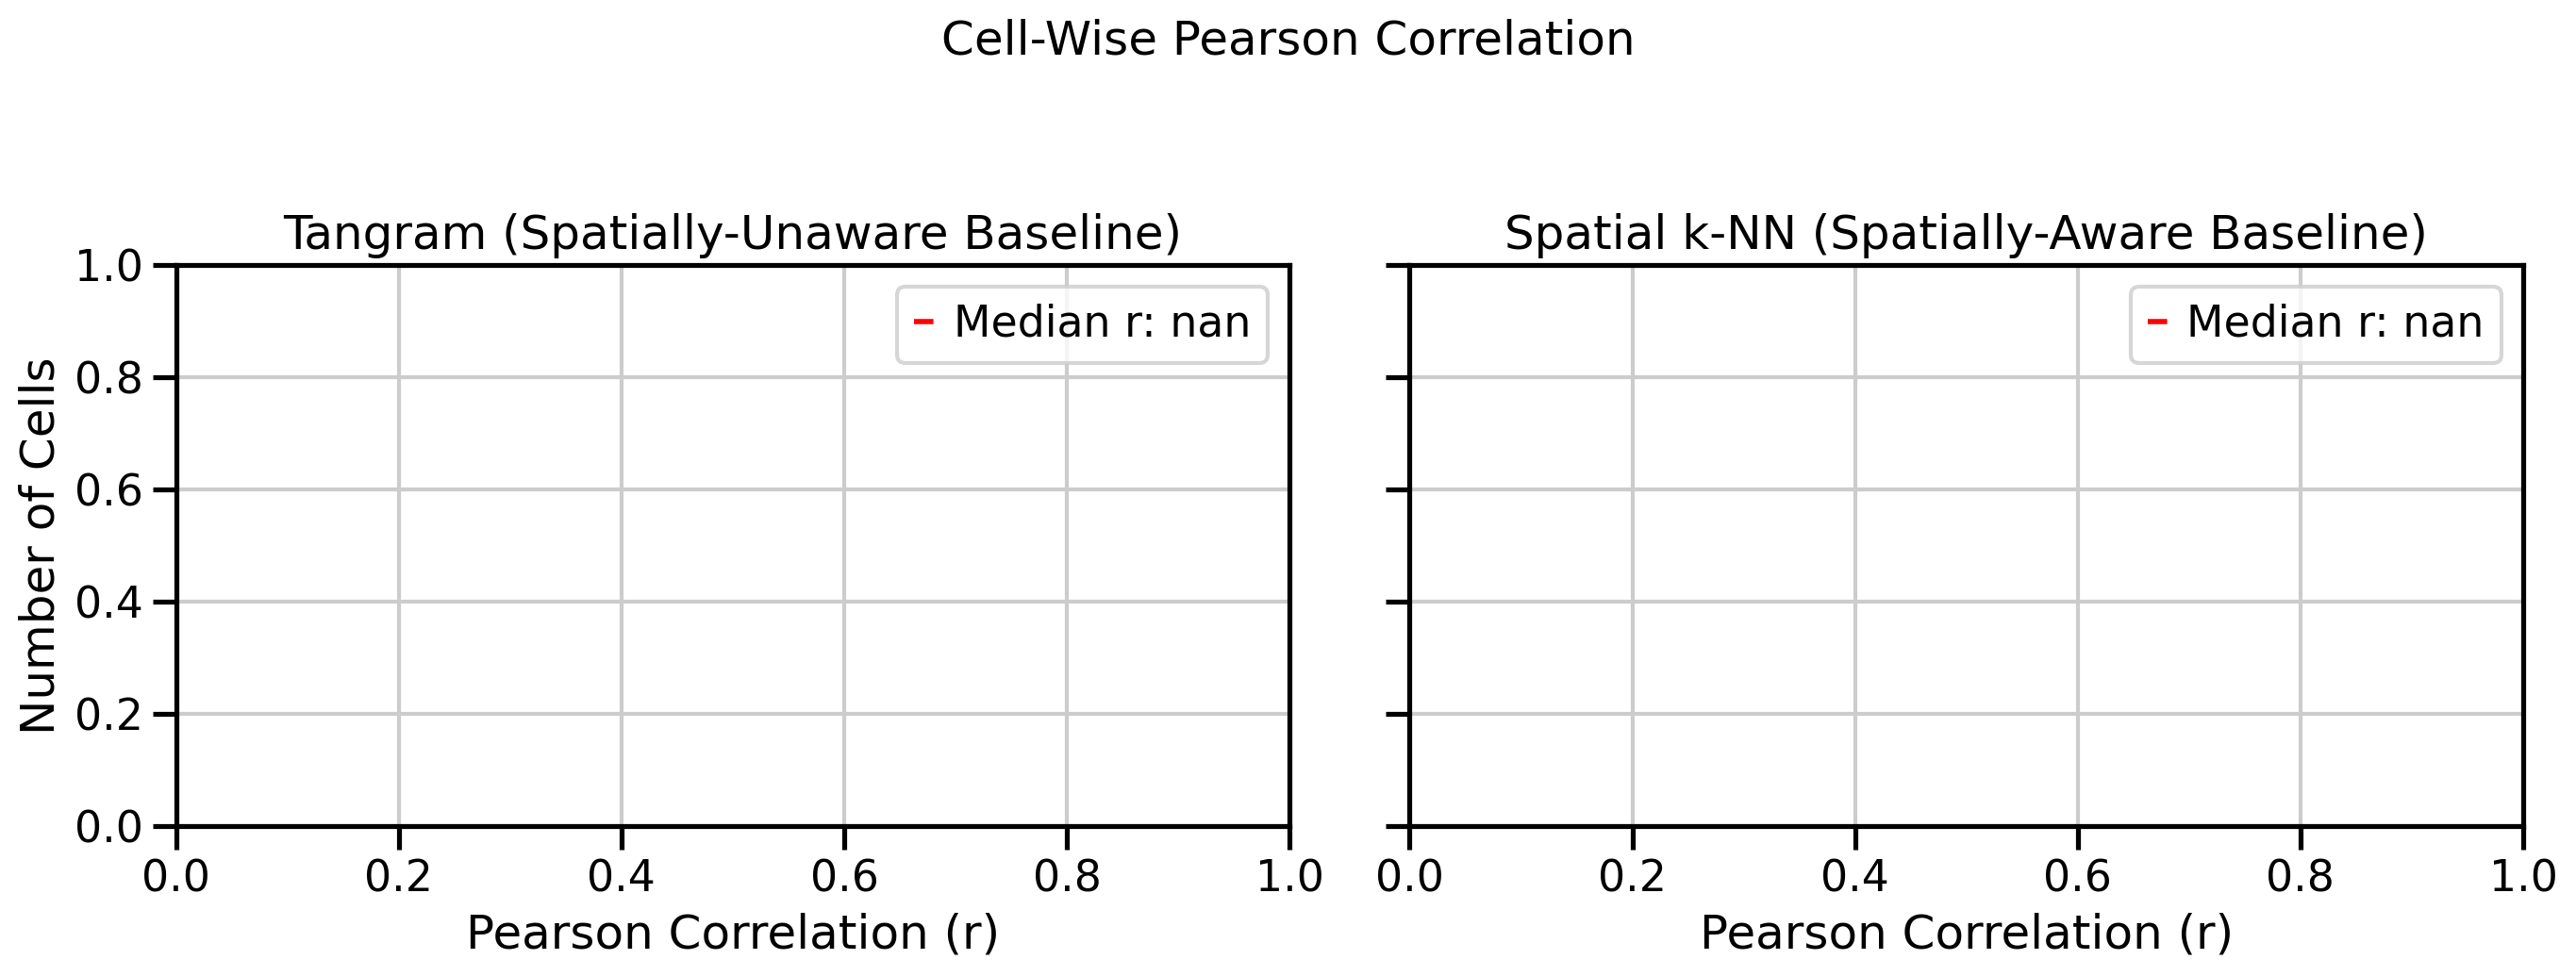

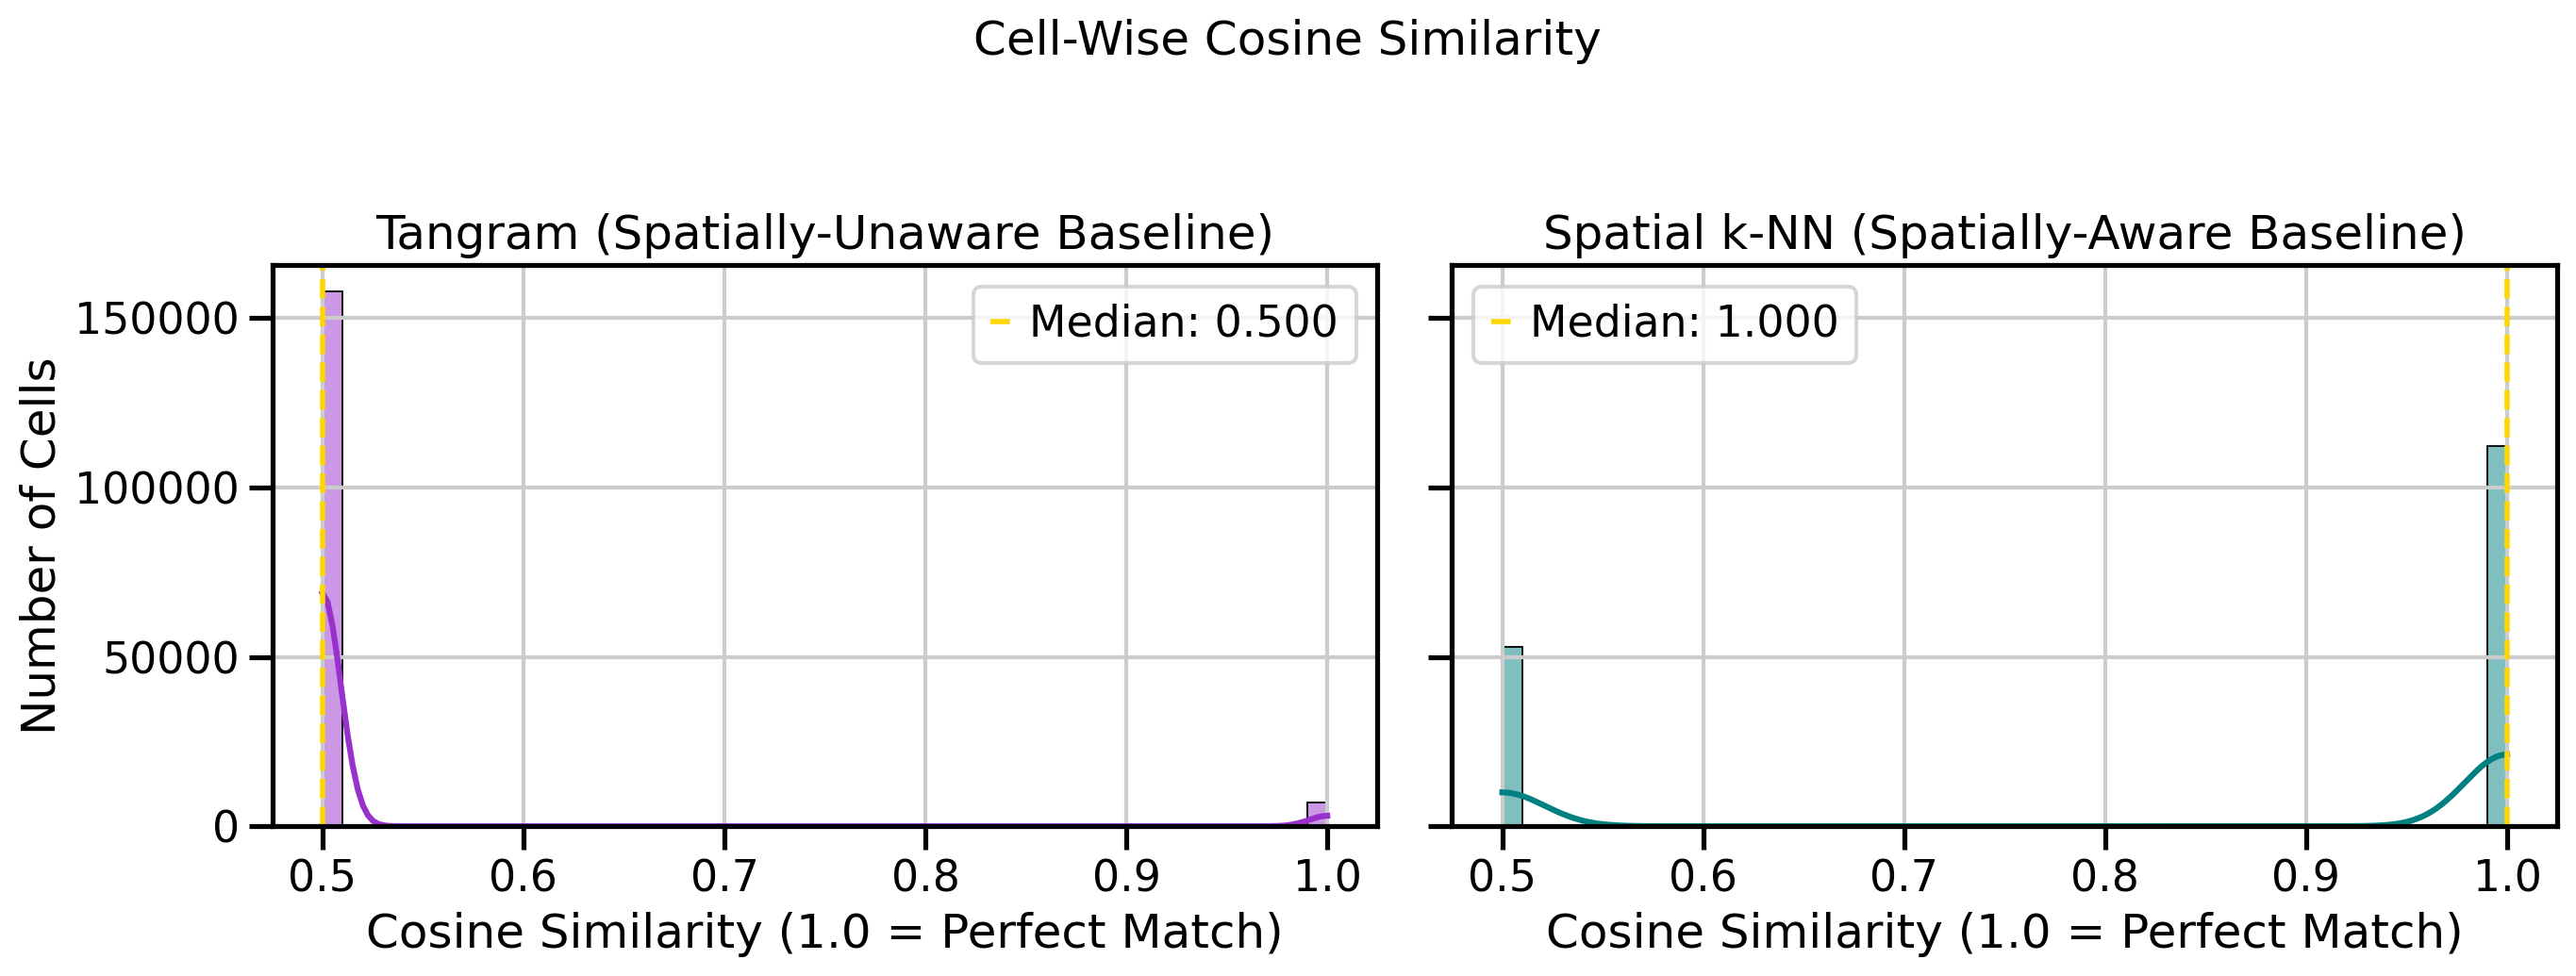

Plots saved as 'Slide_8_Pearson_Histogram.png' and 'Slide_9_Cosine_Histogram.png'!


In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import paired_cosine_distances

print("Loading saved data...")
# NOTE: If you saved using Cell 7.5, use the Checkpoint file. 
# If you successfully ran Cell 9 before the crash, use the _IMPUTED and _REFERENCE files.
# Adjust the filenames below to match exactly what is on your Mac!
try:
    ad_sp = sc.read_h5ad("GSE315411_ad_sp_IMPUTED.h5ad")
    ad_sc = sc.read_h5ad("GSE315411_ad_sc_REFERENCE.h5ad")
except FileNotFoundError:
    print("Export files not found, trying the unified checkpoint...")
    ad_sp = sc.read_h5ad("GSE315411_Midterm_Checkpoint.h5ad")
    ad_sc = sc.read_h5ad("GSE315411_Dual.h5ad") # The original reference

print("Data loaded! Extracting the 10,000-cell microenvironment...")

# 1. Isolate the 10,000 cells we cropped
eval_mask = ad_sp.obs['in_10k_crop'].values

# 2. Extract into dense arrays (Only takes ~200MB of RAM)
true_eval = ad_sc[eval_mask, :].X.toarray() if hasattr(ad_sc.X, 'toarray') else np.array(ad_sc[eval_mask, :].X)
tangram_eval = ad_sp.obsm['imputed_tangram_prime'][eval_mask, :]
knn_eval = ad_sp.obsm['imputed_knn_prime'][eval_mask, :]

# 3. Handle the genes Tangram dropped (the NaNs)
valid_cols = ~np.isnan(tangram_eval[0])
true_clean = true_eval[:, valid_cols]
tangram_clean = tangram_eval[:, valid_cols]
knn_clean = knn_eval[:, valid_cols]

# ==========================================
# PART A: CELL-WISE PEARSON CORRELATION
# ==========================================
print("Calculating Pearson Correlation...")
tangram_corrs_cell = []
knn_corrs_cell = []

for i in range(true_clean.shape[0]):
    true_profile = true_clean[i, :]
    tan_profile = tangram_clean[i, :]
    knn_profile = knn_clean[i, :]
    
    if np.var(true_profile) > 0:
        if np.var(tan_profile) > 0:
            r_tan, _ = stats.pearsonr(true_profile, tan_profile)
            tangram_corrs_cell.append(r_tan)
        if np.var(knn_profile) > 0:
            r_knn, _ = stats.pearsonr(true_profile, knn_profile)
            knn_corrs_cell.append(r_knn)

tangram_pearson_series = pd.Series(tangram_corrs_cell).dropna()
knn_pearson_series = pd.Series(knn_corrs_cell).dropna()

# ==========================================
# PART B: CELL-WISE COSINE SIMILARITY
# ==========================================
print("Calculating Cosine Similarity...")
tangram_cosine = 1 - paired_cosine_distances(true_clean, tangram_clean)
knn_cosine = 1 - paired_cosine_distances(true_clean, knn_clean)

tangram_cos_series = pd.Series(tangram_cosine)
knn_cos_series = pd.Series(knn_cosine)

print("\n--- FINAL METRICS ---")
print(f"Pearson - Tangram Median: {tangram_pearson_series.median():.3f} | k-NN Median: {knn_pearson_series.median():.3f}")
print(f"Cosine  - Tangram Median: {tangram_cos_series.median():.3f} | k-NN Median: {knn_cos_series.median():.3f}")

# ==========================================
# PART C: GENERATE PRESENTATION PLOTS
# ==========================================
sns.set_context("talk") # Makes fonts larger for presentations

# Plot 1: Pearson Correlation (For Slide 8)
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)
sns.histplot(tangram_pearson_series, bins=50, kde=True, color='royalblue', ax=axes1[0])
axes1[0].axvline(tangram_pearson_series.median(), color='red', linestyle='dashed', linewidth=2, label=f'Median r: {tangram_pearson_series.median():.3f}')
axes1[0].set_title('Tangram (Spatially-Unaware Baseline)')
axes1[0].set_xlabel('Pearson Correlation (r)')
axes1[0].set_ylabel('Number of Cells')
axes1[0].legend()

sns.histplot(knn_pearson_series, bins=50, kde=True, color='seagreen', ax=axes1[1])
axes1[1].axvline(knn_pearson_series.median(), color='red', linestyle='dashed', linewidth=2, label=f'Median r: {knn_pearson_series.median():.3f}')
axes1[1].set_title('Spatial k-NN (Spatially-Aware Baseline)')
axes1[1].set_xlabel('Pearson Correlation (r)')
axes1[1].legend()

fig1.suptitle('Cell-Wise Pearson Correlation', fontsize=18, y=1.05)
plt.tight_layout()
plt.savefig("Slide_8_Pearson_Histogram.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Cosine Similarity (For Slide 9)
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)
sns.histplot(tangram_cos_series, bins=50, kde=True, color='darkorchid', ax=axes2[0])
axes2[0].axvline(tangram_cos_series.median(), color='gold', linestyle='dashed', linewidth=2, label=f'Median: {tangram_cos_series.median():.3f}')
axes2[0].set_title('Tangram (Spatially-Unaware Baseline)')
axes2[0].set_xlabel('Cosine Similarity (1.0 = Perfect Match)')
axes2[0].set_ylabel('Number of Cells')
axes2[0].legend()

sns.histplot(knn_cos_series, bins=50, kde=True, color='teal', ax=axes2[1])
axes2[1].axvline(knn_cos_series.median(), color='gold', linestyle='dashed', linewidth=2, label=f'Median: {knn_cos_series.median():.3f}')
axes2[1].set_title('Spatial k-NN (Spatially-Aware Baseline)')
axes2[1].set_xlabel('Cosine Similarity (1.0 = Perfect Match)')
axes2[1].legend()

fig2.suptitle('Cell-Wise Cosine Similarity', fontsize=18, y=1.05)
plt.tight_layout()
plt.savefig("Slide_9_Cosine_Histogram.png", dpi=300, bbox_inches='tight')
plt.show()

print("Plots saved as 'Slide_8_Pearson_Histogram.png' and 'Slide_9_Cosine_Histogram.png'!")

In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading saved data...")
try:
    ad_sp = sc.read_h5ad("GSE315411_ad_sp_IMPUTED.h5ad")
    ad_sc = sc.read_h5ad("GSE315411_ad_sc_REFERENCE.h5ad")
except FileNotFoundError:
    print("Export files not found, trying the unified checkpoint...")
    ad_sp = sc.read_h5ad("GSE315411_Midterm_Checkpoint.h5ad")
    ad_sc = sc.read_h5ad("GSE315411_Dual.h5ad")

print("Extracting the 10,000-cell microenvironment...")
eval_mask = ad_sp.obs['in_10k_crop'].values

true_eval = ad_sc[eval_mask, :].X.toarray() if hasattr(ad_sc.X, 'toarray') else np.array(ad_sc[eval_mask, :].X)
tangram_eval = ad_sp.obsm['imputed_tangram_prime'][eval_mask, :]
knn_eval = ad_sp.obsm['imputed_knn_prime'][eval_mask, :]

print("Calculating Gene-Wise Spatial Correlation (Tangram Paper Standard)...")
tangram_corrs_gene = []
knn_corrs_gene = []

n_genes = true_eval.shape[1]

# Loop through genes instead of cells
for j in range(n_genes):
    true_gene = true_eval[:, j]
    tan_gene = tangram_eval[:, j]
    knn_gene = knn_eval[:, j]
    
    # Filter out cells where Tangram dropped the gene (NaNs)
    valid = ~np.isnan(tan_gene) & ~np.isnan(knn_gene)
    
    # Only calculate if the gene actually has variance across this tissue crop
    if np.sum(valid) > 2 and np.var(true_gene[valid]) > 0:
        if np.var(tan_gene[valid]) > 0:
            r_tan, _ = stats.pearsonr(true_gene[valid], tan_gene[valid])
            tangram_corrs_gene.append(r_tan)
            
        if np.var(knn_gene[valid]) > 0:
            r_knn, _ = stats.pearsonr(true_gene[valid], knn_gene[valid])
            knn_corrs_gene.append(r_knn)

tangram_series = pd.Series(tangram_corrs_gene).dropna()
knn_series = pd.Series(knn_corrs_gene).dropna()

print(f"\nSuccessfully evaluated {len(tangram_series)} highly variable Prime genes.")
print(f"Tangram Median r: {tangram_series.median():.3f} | k-NN Median r: {knn_series.median():.3f}")

# ==========================================
# GENERATE CDF PLOT (Tangram Style)
# ==========================================
sns.set_context("talk")
plt.figure(figsize=(10, 6), facecolor='white')

# ecdfplot creates the Cumulative Distribution Function
sns.ecdfplot(data=tangram_series, label=f'Tangram Baseline (Median r: {tangram_series.median():.3f})', 
             color='royalblue', linewidth=3)
sns.ecdfplot(data=knn_series, label=f'Spatial k-NN Baseline (Median r: {knn_series.median():.3f})', 
             color='seagreen', linewidth=3)

plt.title('Gene-Wise Spatial Imputation Accuracy', fontsize=20, pad=15)
plt.xlabel('Pearson Correlation (r)', fontsize=16)
plt.ylabel('Cumulative Fraction of Genes', fontsize=16)

# Standardize axes to show the full correlation spectrum
plt.xlim(-0.2, 1.0) 
plt.ylim(0, 1.05)

plt.legend(fontsize=14, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("Slide_8_Tangram_Style_CDF.png", dpi=300, bbox_inches='tight')
print("\nPlot saved as 'Slide_8_Tangram_Style_CDF.png'!")
plt.show()

Loading saved data...
